In [11]:
!pip install lightkurve

In [12]:
import lightkurve as lk
import matplotlib.pyplot as plt

In [13]:
#define TIC e.g. TIC 237913194
TIC = 'TIC 237913194' #Confirmed Planet 
#search what data is available for a given target
sector_data = lk.search_lightcurve(TIC)
sector_data

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 29,2020,SPOC,20,237913194,0.0
1,TESS Sector 29,2020,SPOC,120,237913194,0.0
2,TESS Sector 28,2020,SPOC,120,237913194,0.0
3,TESS Sector 69,2023,SPOC,120,237913194,0.0
4,TESS Sector 68,2023,SPOC,120,237913194,0.0
5,TESS Sector 01,2018,TESS-SPOC,1800,237913194,0.0
6,TESS Sector 02,2018,TESS-SPOC,1800,237913194,0.0
7,TESS Sector 29,2020,TESS-SPOC,600,237913194,0.0
8,TESS Sector 28,2020,TESS-SPOC,600,237913194,0.0


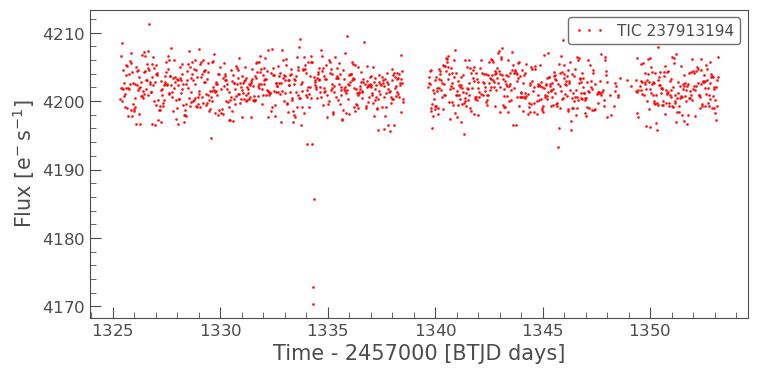

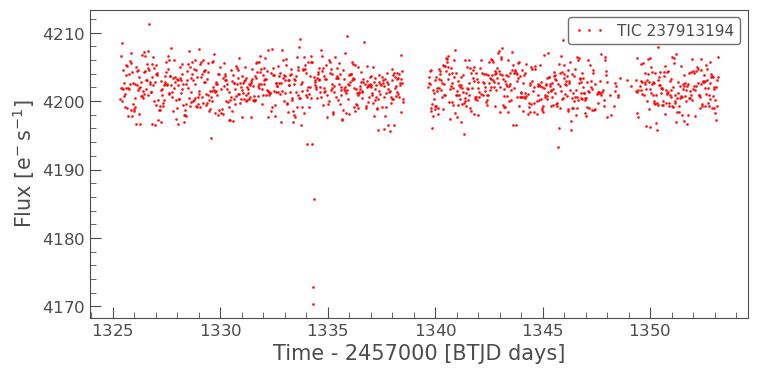

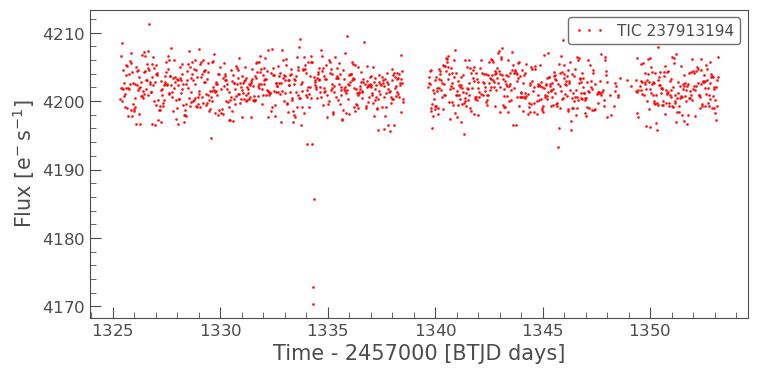

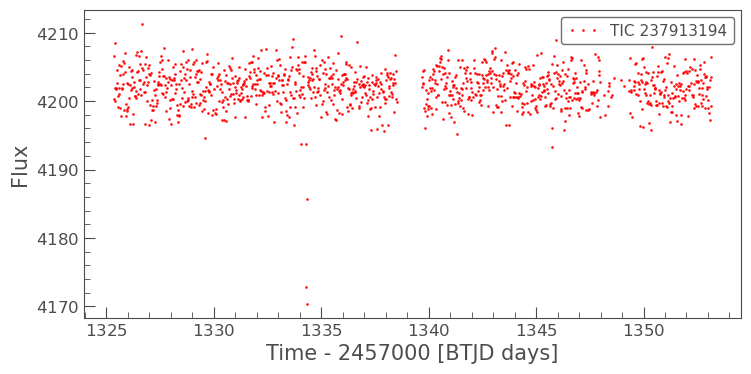

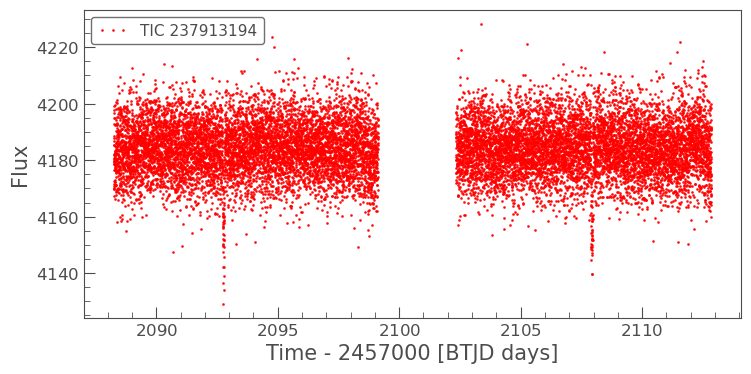

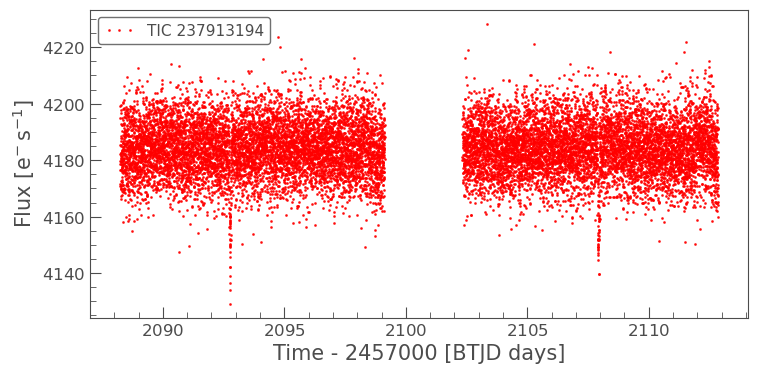

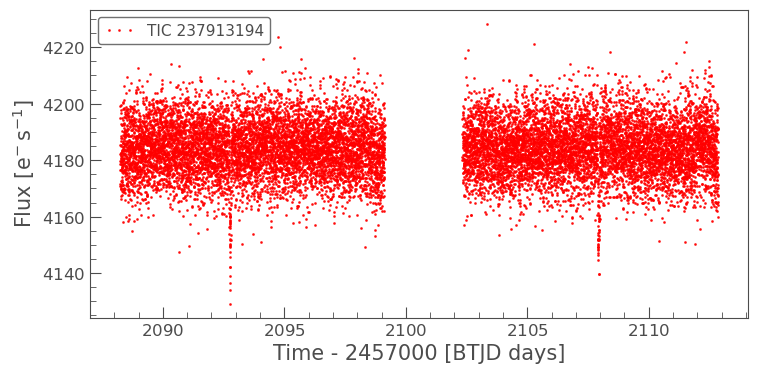

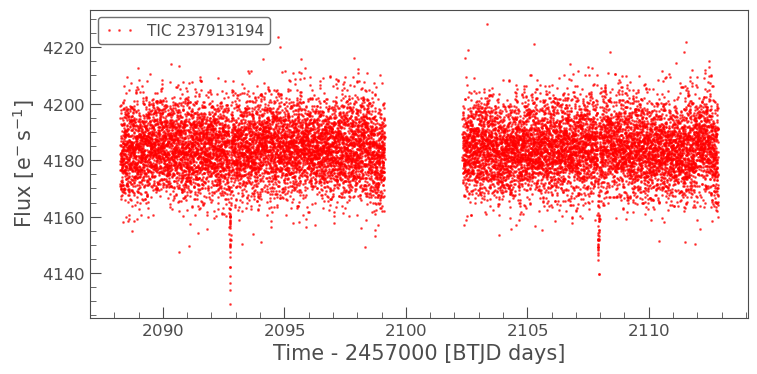

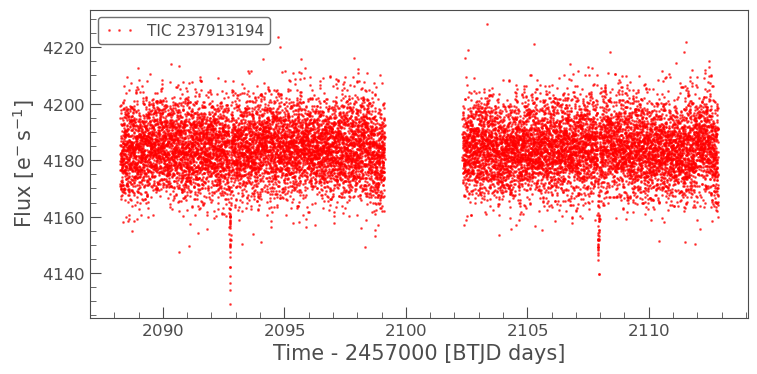

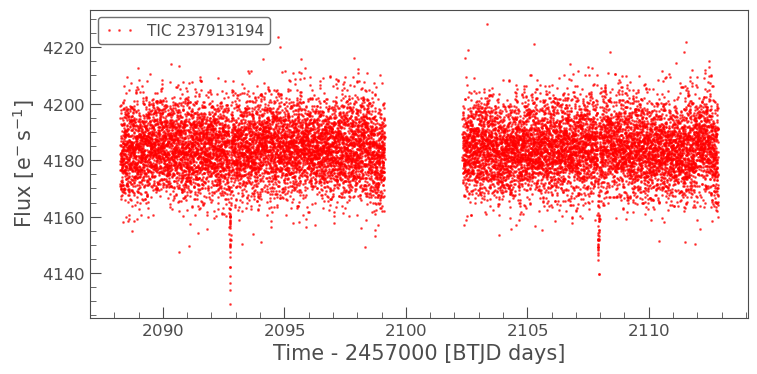

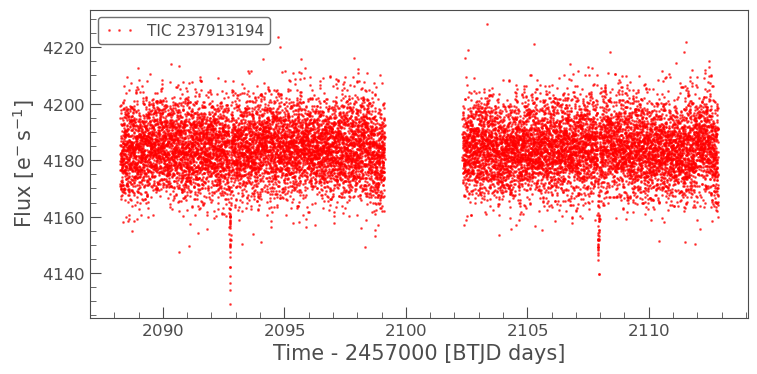

In [21]:
#plot the lightcurve to see what it looks like
lc = sector_data[1].download()
lc.plot(linewidth=0, marker='.', color='red', alpha=0.6 )
plt.show()
# Changed alpha from 2 to 0.8 (must be between 0 and 1)


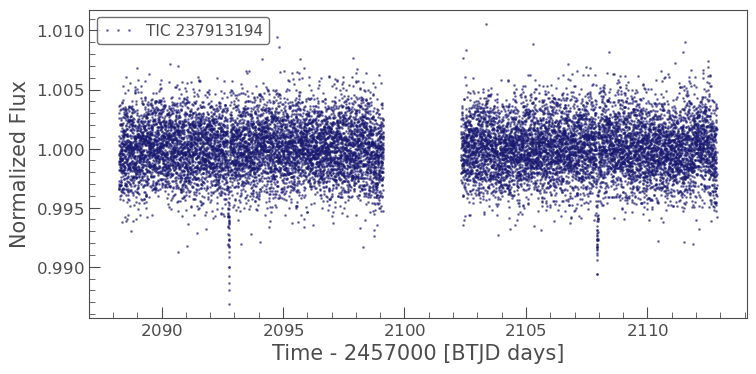

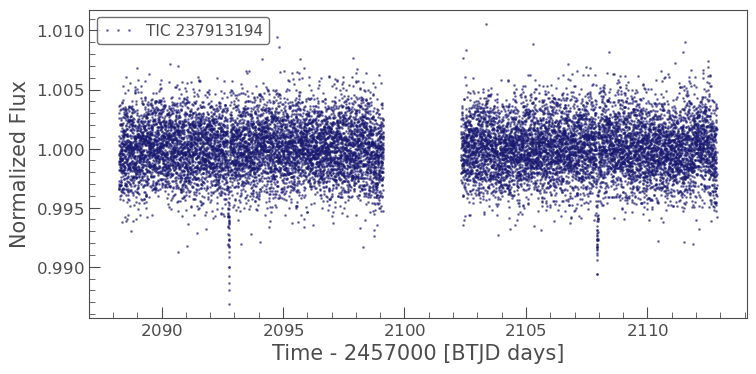

In [23]:
lc_norm = lc.normalize()
lc_norm.plot(linewidth= 0, marker = '.', color = 'midnightblue', alpha = 0.5 )
plt.show()

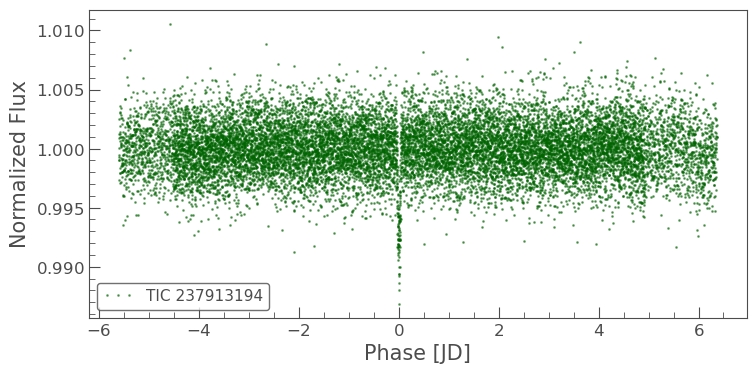

In [26]:
#phase folding 
t0 = 2458319.15055-2457000
period = 15.168865
lc_phased = lc_norm.fold(period = period, epoch_time = t0)
lc_phased.plot(linewidth =0, color = 'darkgreen', marker='.', alpha=0.5 )
plt.show()

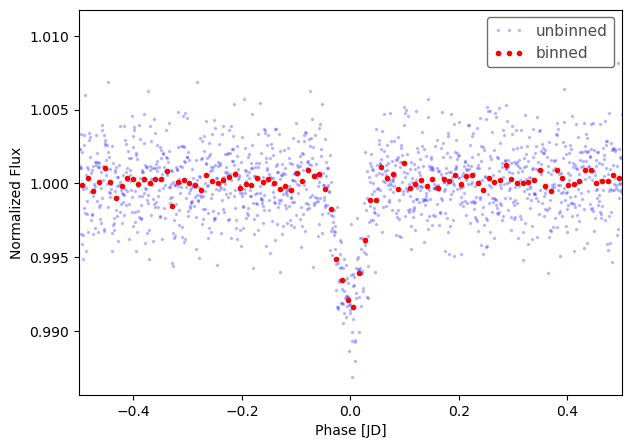

In [28]:
lc_phased_binned = lc_phased.bin (15/24/60) #bin width =15 mins. it has to be in terms of minutes when using Lightkurve
fig, ax = plt.subplots (figsize = (7,5))
lc_phased.plot(ax = ax, marker = '.', linewidth = 0, color = 'blue', alpha = 0.2, markersize = 3, label = "unbinned")
lc_phased_binned.plot(ax= ax, marker = 'o', linewidth= 0, color = 'red', alpha = 1, markersize = 3, label = "binned")
plt.xlim(-0.5,0.5)
plt.show()